# Sparse reduction backend: sanity checks

`torch-weighttracker` computes per-unit quantities (active slices, L2 norms, parameter
counts, BOPs, ...) from *reduction plans*. The reference ("loop") backend runs one small
reduction plus one scatter per module, which on a GPU means hundreds of tiny kernel launches.

The **sparse backend** (now the default) lowers every supported op into a couple of sparse
matrix–vector products over one flattened vector $z$ of all source weights:

$$
\text{out} = M\,f(z) \qquad\text{or}\qquad \text{out} = D\;g\!\big(E\,f(z)\big)
$$

* $f$ is elementwise: $w^2$ for L2, $\mathbb{1}[w\neq 0]$ for active counts, $|w|$, ...
* $E$ maps weight elements to **slices** (a row or column of a weight), $g$ is a slice
  post-op (`any`, `sqrt`), and $D$ scatters slices into canonical units.
* Ops it can't express (e.g. fused QKV) and very large tensors stay on the loop path, inside
  the same calculation, so results are always exact.

This notebook checks the backend on small, hand-checkable examples:

1. **Tree**: the canonical-group structure of ResNet-20
2. **Count**: what `ACTIVE_UNITS` counts, and the two matrices that compute it
3. **Group lasso**: per-unit contributions and gradients, by hand vs. both backends
4. **BOPs**: structured BOPs compression under progressive channel pruning
5. **Performance**: loop vs. sparse, on this machine and on an RTX 3060

In [1]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from matplotlib.colors import to_rgba
from matplotlib.patches import FancyBboxPatch, Patch

REPO = Path.cwd().resolve().parent if Path.cwd().name == "sanity_checks" else Path.cwd().resolve()
sys.path.insert(0, str(REPO))

from tests.fixtures_models import CifarResNet20
from torch_weighttracker import WeightTracker
from torch_weighttracker.calculations import CalcType

PALETTE = [
    "#4C78A8", "#F58518", "#54A24B", "#E45756", "#72B7B2", "#EECA3B", "#B279A2",
    "#FF9DA6", "#9D755D", "#BAB0AC", "#2F4B7C", "#A05195", "#D45087",
]
LOOP_COLOR, SPARSE_COLOR = "#9AA5B1", "#E4572E"
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.titleweight": "bold", "axes.titlesize": 11, "font.size": 9.5,
})

def color(i):
    return PALETTE[i % len(PALETTE)]

def tracker_pair(model, example, **kwargs):
    # The same model under both backends.
    return (
        WeightTracker(model, example_inputs=example, reduction_backend="sparse", **kwargs),
        WeightTracker(model, example_inputs=example, reduction_backend="loop", **kwargs),
    )

torch.manual_seed(0)
print("torch", torch.__version__)

torch 2.11.0


## 1. Tree: how ResNet-20 couples channels

A **canonical group** is a set of channels that must be pruned together. One group can own
the output channels of several convs and BatchNorms plus the input channels of the layers
that consume them. In ResNet-20 the residual additions tie whole stages together.

Left: groups (box height = number of units). Right: weighted modules in network order.
A solid edge means the group owns that module's **output** channels, a dashed edge its
**input** channels.

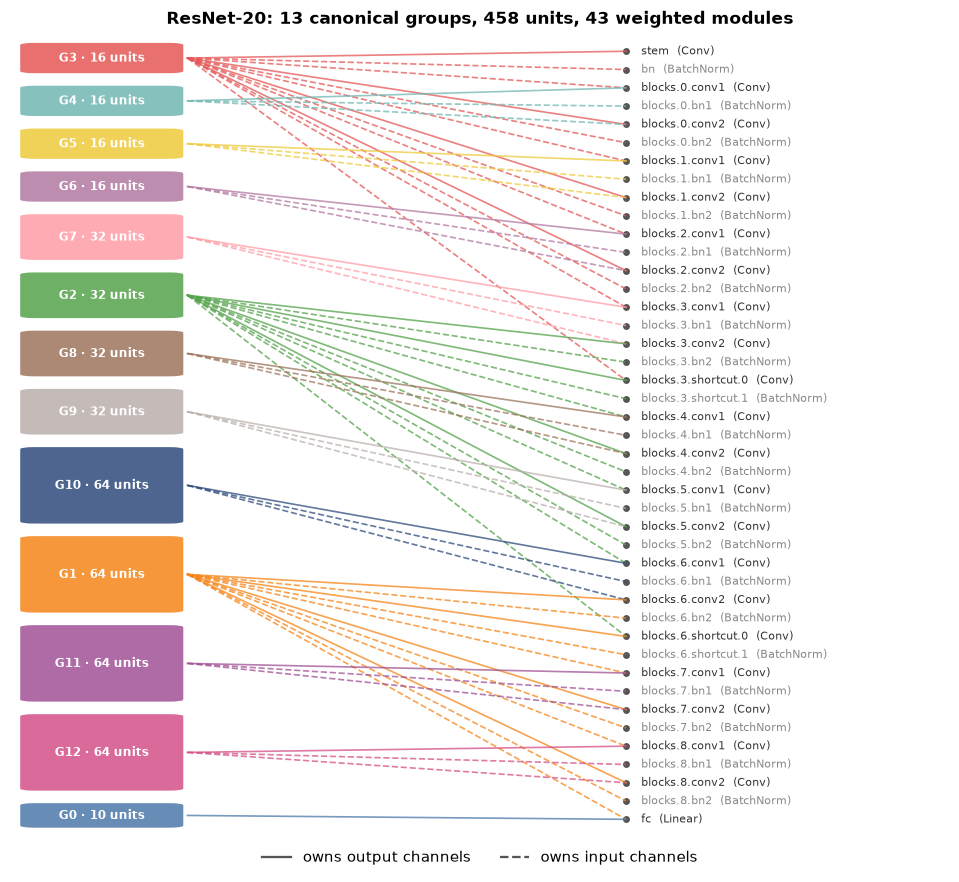

G0   10 units   1 members  fc
G1   64 units  11 members  blocks.6.bn2, blocks.6.conv2, blocks.6.shortcut.0, blocks.6.shortcut.1, blocks.7.bn2, blocks.7.conv1, blocks.7
G2   32 units  12 members  blocks.3.bn2, blocks.3.conv2, blocks.3.shortcut.0, blocks.3.shortcut.1, blocks.4.bn2, blocks.4.conv1, blocks.4
G3   16 units  13 members  blocks.0.bn2, blocks.0.conv1, blocks.0.conv2, blocks.1.bn2, blocks.1.conv1, blocks.1.conv2, blocks.2.bn2, bloc
G4   16 units   3 members  blocks.0.bn1, blocks.0.conv1, blocks.0.conv2
G5   16 units   3 members  blocks.1.bn1, blocks.1.conv1, blocks.1.conv2
G6   16 units   3 members  blocks.2.bn1, blocks.2.conv1, blocks.2.conv2
G7   32 units   3 members  blocks.3.bn1, blocks.3.conv1, blocks.3.conv2
G8   32 units   3 members  blocks.4.bn1, blocks.4.conv1, blocks.4.conv2
G9   32 units   3 members  blocks.5.bn1, blocks.5.conv1, blocks.5.conv2
G10  64 units   3 members  blocks.6.bn1, blocks.6.conv1, blocks.6.conv2
G11  64 units   3 members  blocks.7.bn1, blocks.7.co

In [2]:
resnet = CifarResNet20().eval()
tracker = WeightTracker(resnet, example_inputs=torch.randn(1, 3, 32, 32))
groups = [g for g in tracker.canonical_groups if g.members]
names = {m: n for n, m in resnet.named_modules()}

modules = []
for module in resnet.modules():
    if isinstance(module, (nn.Conv2d, nn.BatchNorm2d, nn.Linear)):
        modules.append(module)
row_of = {m: i for i, m in enumerate(modules)}
groups.sort(key=lambda g: min(row_of[m.module] for m in g.members))

fig, ax = plt.subplots(figsize=(11, 9.5))
n_rows = len(modules)
total_units = sum(g.length for g in groups)
gap = 0.6
scale = (n_rows - gap * (len(groups) - 1)) / total_units
y = n_rows
group_y = {}
min_h = 0.9
scale = (n_rows - gap * (len(groups) - 1) - min_h * len(groups)) / total_units
for g in groups:
    h = min_h + g.length * scale
    y -= h
    group_y[g.group_id] = y + h / 2
    ax.add_patch(FancyBboxPatch((0.0, y), 1.6, h, boxstyle="round,pad=0.02,rounding_size=0.15",
                                fc=to_rgba(color(g.group_id), 0.85), ec="white", lw=1.5))
    ax.text(0.8, y + h / 2, f"G{g.group_id} · {g.length} units", ha="center", va="center",
            color="white", fontsize=8, fontweight="bold")
    y -= gap

for i, module in enumerate(modules):
    yy = n_rows - i - 0.5
    kind = type(module).__name__.replace("2d", "")
    ax.text(6.15, yy, f"{names[module]}  ({kind})", va="center", fontsize=7.5,
            color="#333" if kind != "BatchNorm" else "#888")
    ax.plot([6.0], [yy], "o", ms=3.5, color="#555")

for g in groups:
    for member in g.members:
        yy = n_rows - row_of[member.module] - 0.5
        axis = getattr(member.unit_axis, "value", str(member.unit_axis))
        style = "-" if "out" in axis else "--"
        ax.plot([1.65, 6.0], [group_y[g.group_id], yy], style, lw=1.1,
                color=color(g.group_id), alpha=0.75)

ax.set_xlim(-0.1, 9.2)
ax.set_ylim(-0.5, n_rows + 0.5)
ax.axis("off")
ax.set_title(f"ResNet-20: {len(groups)} canonical groups, {total_units} units, "
             f"{len(modules)} weighted modules")
ax.legend(handles=[plt.Line2D([], [], color="#555", ls="-", label="owns output channels"),
                   plt.Line2D([], [], color="#555", ls="--", label="owns input channels")],
          loc="upper center", bbox_to_anchor=(0.5, 0.0), ncol=2, frameon=False)
plt.show()

for g in sorted(groups, key=lambda g: g.group_id):
    print(f"G{g.group_id:<2d} {g.length:3d} units  {len(g.members):2d} members  "
          + ", ".join(sorted({names[m.module] for m in g.members}))[:110])

## 2. Count: what `ACTIVE_UNITS` counts

A tiny MLP `5 → 4 → 3 → 2`. Each unit (one hidden channel) owns a **row** of the
producing layer and a **column** of the consuming layer. `ACTIVE_UNITS` counts the unit's
*slices that still contain a non-zero*, so a unit stays alive until all of its slices are
zero.

We zero some weights by hand:
* unit **u6**: only its row in layer `0` → its column in layer `2` is still live, so 1
* unit **u7**: its row in layer `0` *and* its column in layer `2` → dead (0)
* unit **u2**: part of its row in layer `2` → both slices still live, so 2

In [3]:
torch.manual_seed(1)
mlp = nn.Sequential(nn.Linear(5, 4), nn.ReLU(), nn.Linear(4, 3), nn.ReLU(), nn.Linear(3, 2))
with torch.no_grad():
    mlp[0].weight[1] = 0          # unit 6's producing row (group 2, position 1)
    mlp[0].weight[2] = 0          # unit 7's producing row ...
    mlp[2].weight[:, 2] = 0       # ... and its consuming column  -> unit 7 dead
    mlp[2].weight[0, :2] = 0      # unit 2: part of its row only

sparse_t, loop_t = tracker_pair(mlp, torch.randn(1, 5))
active_sparse = sparse_t.get_calculation(CalcType.ACTIVE_UNITS)()
active_loop = loop_t.get_calculation(CalcType.ACTIVE_UNITS)()
print(sparse_t.view_structures())
print("\nACTIVE_UNITS sparse:", active_sparse.tolist())
print("ACTIVE_UNITS loop:  ", active_loop.tolist())
assert torch.equal(active_sparse, active_loop)

CanonicalGroups
groups=3 total_units=9

- group 0: units=[0:2) length=2 kind=channel members=1
  members:
    - 4 Linear axis=out_channel layout=plain dest=(0, 1)

- group 1: units=[2:5) length=3 kind=channel members=2
  members:
    - 2 Linear axis=out_channel layout=plain dest=(2, 3, 4)
    - 4 Linear axis=in_channel layout=plain dest=(2, 3, 4)

- group 2: units=[5:9) length=4 kind=channel members=2
  members:
    - 0 Linear axis=out_channel layout=plain dest=(5, 6, 7, 8)
    - 2 Linear axis=in_channel layout=plain dest=(5, 6, 7, 8)

ACTIVE_UNITS sparse: [1.0, 1.0, 2.0, 2.0, 2.0, 2.0, 1.0, 0.0, 2.0]
ACTIVE_UNITS loop:   [1.0, 1.0, 2.0, 2.0, 2.0, 2.0, 1.0, 0.0, 2.0]


The weights coloured by the unit that owns each slice (rows = output channels,
columns = input channels). Grey hatching marks exact zeros, and a cell owned by two units
shows the row unit's colour.

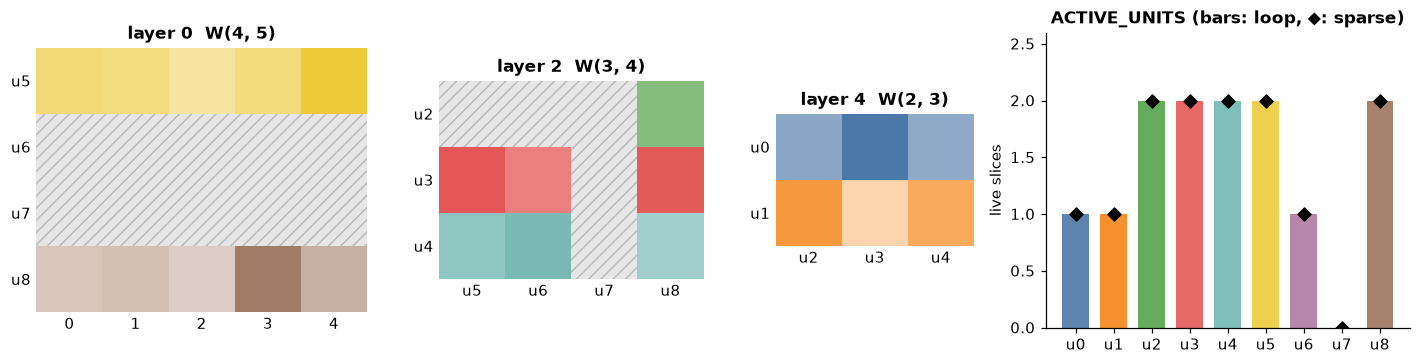

In [4]:
layers = [mlp[0], mlp[2], mlp[4]]
layer_names = {mlp[0]: "0", mlp[2]: "2", mlp[4]: "4"}
groups = sparse_t.canonical_groups
row_unit, col_unit = {}, {}
for g in groups:
    for member in g.members:
        axis = getattr(member.unit_axis, "value", str(member.unit_axis))
        target = row_unit if "out" in axis else col_unit
        dest = member.destination
        units = list(range(dest.start, dest.start + dest.length)) if hasattr(dest, "start") else list(dest.indices)
        target[member.module] = units

fig, axes = plt.subplots(1, 4, figsize=(13, 3.4), gridspec_kw={"width_ratios": [5, 4, 3, 5.5]})
for ax, layer in zip(axes[:3], layers):
    w = layer.weight.detach()
    rgba = np.ones((*w.shape, 4))
    for r in range(w.shape[0]):
        for c in range(w.shape[1]):
            unit = row_unit.get(layer, [None] * w.shape[0])[r]
            if unit is None:
                unit = col_unit.get(layer, [None] * w.shape[1])[c]
            if w[r, c] == 0:
                rgba[r, c] = to_rgba("#E6E6E6")
            else:
                alpha = 0.35 + 0.65 * float(w[r, c].abs() / w.abs().max())
                rgba[r, c] = to_rgba(color(unit), alpha)
    ax.imshow(rgba)
    for r in range(w.shape[0]):
        for c in range(w.shape[1]):
            if w[r, c] == 0:
                ax.add_patch(plt.Rectangle((c - .5, r - .5), 1, 1, fill=False, hatch="///", ec="#BBB", lw=0))
    ax.set_title(f"layer {layer_names[layer]}  W{tuple(w.shape)}")
    ax.set_yticks(range(w.shape[0]), [f"u{u}" for u in row_unit.get(layer, [""] * w.shape[0])] if layer in row_unit else range(w.shape[0]))
    ax.set_xticks(range(w.shape[1]), [f"u{u}" for u in col_unit[layer]] if layer in col_unit else range(w.shape[1]))
    ax.tick_params(length=0)
    for s in ax.spines.values():
        s.set_visible(False)

ax = axes[3]
units = np.arange(len(active_sparse))
ax.bar(units, active_loop.numpy(), color=[to_rgba(color(int(u)), 0.9) for u in units], width=0.7, label="loop")
ax.scatter(units, active_sparse.numpy(), marker="D", s=36, color="black", zorder=3, label="sparse")
ax.set_xticks(units, [f"u{u}" for u in units])
ax.set_ylim(0, 2.6)
ax.set_title("ACTIVE_UNITS (bars: loop, ◆: sparse)")
ax.set_ylabel("live slices")
plt.tight_layout()
plt.show()

### The two matrices behind it

With `nonzero` as $f$ and `any` as $g$, the calculation is
$\text{ACTIVE} = D\,\big[\,E\,\mathbb{1}[z \neq 0] > 0\,\big]$. $E$ has one row per slice and
one column per weight element. $D$ has one row per unit and one column per slice.
The colours match the units above.

kind: f=nonzero, post=any; E (16, 38), D (9, 16)


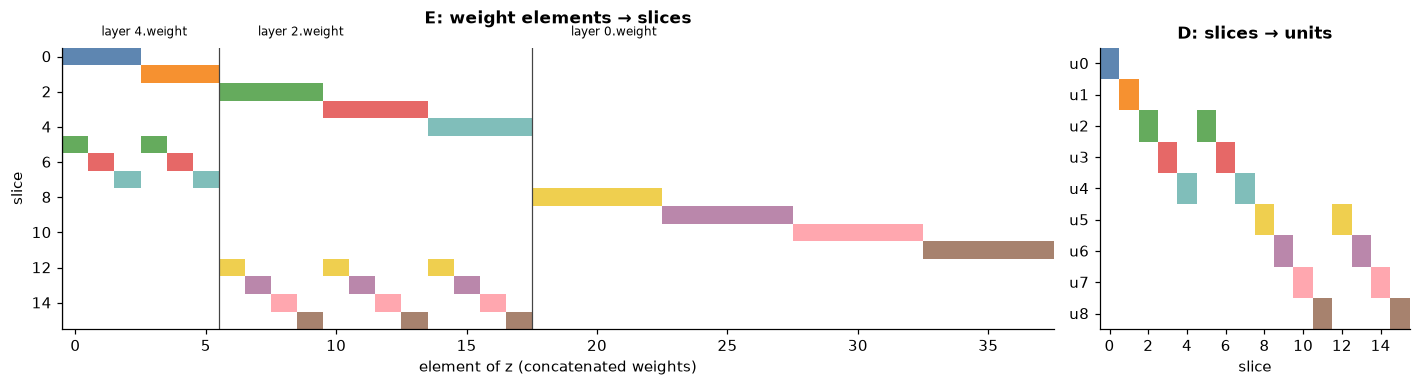

D·[E·1(z≠0) > 0] = [1.0, 1.0, 2.0, 2.0, 2.0, 2.0, 1.0, 0.0, 2.0]


In [5]:
calc = sparse_t.get_calculation(CalcType.ACTIVE_UNITS)
executor = calc.sparse_executor
kind = executor.matrices()[0]
E, D = (m.to_dense() for m in kind.matrices)
print(f"kind: f={kind.elementwise}, post={kind.post}; E {tuple(E.shape)}, D {tuple(D.shape)}")

slice_unit = D.argmax(0)                      # each slice feeds exactly one unit here
E_rgba = np.ones((*E.shape, 4))
for s in range(E.shape[0]):
    for e in torch.nonzero(E[s]).flatten().tolist():
        E_rgba[s, e] = to_rgba(color(int(slice_unit[s])), 0.9)
D_rgba = np.ones((*D.shape, 4))
for u, s in torch.nonzero(D).tolist():
    D_rgba[u, s] = to_rgba(color(u), 0.9)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 3.6), gridspec_kw={"width_ratios": [3.2, 1]})
a1.imshow(E_rgba, aspect="auto", interpolation="nearest")
bounds = np.cumsum((0,) + executor.source_numels)
for b, ref in zip(bounds[:-1], executor.source_refs):
    a1.axvline(b - 0.5, color="#444", lw=0.8)
    a1.text(b + 1, -1.2, f"layer {layer_names[ref.module]}.weight", fontsize=8)
a1.set_title("E: weight elements → slices", pad=16)
a1.set_xlabel("element of z (concatenated weights)")
a1.set_yticks(range(0, E.shape[0], 2))
a1.set_ylabel("slice")
a2.imshow(D_rgba, aspect="auto", interpolation="nearest")
a2.set_title("D: slices → units")
a2.set_xlabel("slice")
a2.set_xticks(range(0, D.shape[1], 2))
a2.set_yticks(range(D.shape[0]), [f"u{u}" for u in range(D.shape[0])])
plt.tight_layout()
plt.show()

z = executor.gather_sources()
by_hand = D @ ((E @ (z != 0).float()) > 0).float()
print("D·[E·1(z≠0) > 0] =", by_hand.tolist())
assert torch.equal(by_hand, active_sparse)

## 3. Group lasso

$$
\mathrm{GL} = \sum_{u} \sqrt{p_u}\;\lVert w_u \rVert_2 ,\qquad
\lVert w_u\rVert_2 = \sqrt{\textstyle\sum_{\text{slices } s\text{ of } u}\ \sum_{e\in s} w_e^2}
$$

where $p_u$ is the parameter count of unit $u$ (`PARAM_PR_UNIT`). We compute every term by
hand from the weight slices and compare it with both backends, then compare the gradients
$\partial \mathrm{GL}/\partial W$.

In [6]:
torch.manual_seed(2)
gl_mlp = nn.Sequential(nn.Linear(5, 4), nn.ReLU(), nn.Linear(4, 3), nn.ReLU(), nn.Linear(3, 2))
with torch.no_grad():
    gl_mlp[0].weight[3] = 0
    gl_mlp[2].weight[:, 3] = 0            # unit 8 fully dead -> contributes 0, zero gradient
sparse_t, loop_t = tracker_pair(gl_mlp, torch.randn(1, 5))

# --- by hand -------------------------------------------------------------
W0, W2, W4 = (gl_mlp[i].weight.detach() for i in (0, 2, 4))
slices = {}                                  # unit -> list of weight slices
for u in range(2):  slices[u] = [W4[u]]                              # group 0: rows of layer 4
for k in range(3):  slices[2 + k] = [W2[k], W4[:, k]]                # group 1
for k in range(4):  slices[5 + k] = [W0[k], W2[:, k]]                # group 2
norm_by_hand = torch.stack([torch.sqrt(sum((s ** 2).sum() for s in slices[u])) for u in range(9)])
p_u = sparse_t.get_calculation(CalcType.PARAM_PR_UNIT)().detach()
terms_by_hand = p_u.sqrt() * norm_by_hand
gl_by_hand = terms_by_hand.sum()

def gl_and_grads(owner):
    for p in gl_mlp.parameters():
        p.grad = None
    loss = owner.create_regularizer("group_lasso")()
    loss.backward()
    return loss.detach(), [gl_mlp[i].weight.grad.clone() for i in (0, 2, 4)]

gl_sparse, g_sparse = gl_and_grads(sparse_t)
gl_loop, g_loop = gl_and_grads(loop_t)
norm_sparse = sparse_t.get_calculation(CalcType.L2_NORM_PR_UNIT)().detach()

print(f"GL by hand   = {gl_by_hand:.6f}")
print(f"GL sparse    = {gl_sparse:.6f}")
print(f"GL loop      = {gl_loop:.6f}")
print("max |∂GL/∂W| difference sparse vs loop:",
      max(float((a - b).abs().max()) for a, b in zip(g_sparse, g_loop)))
torch.testing.assert_close(norm_sparse, norm_by_hand)
torch.testing.assert_close(gl_sparse, gl_by_hand)
torch.testing.assert_close(gl_sparse, gl_loop)

GL by hand   = 10.448729
GL sparse    = 10.448728
GL loop      = 10.448729
max |∂GL/∂W| difference sparse vs loop: 2.384185791015625e-07


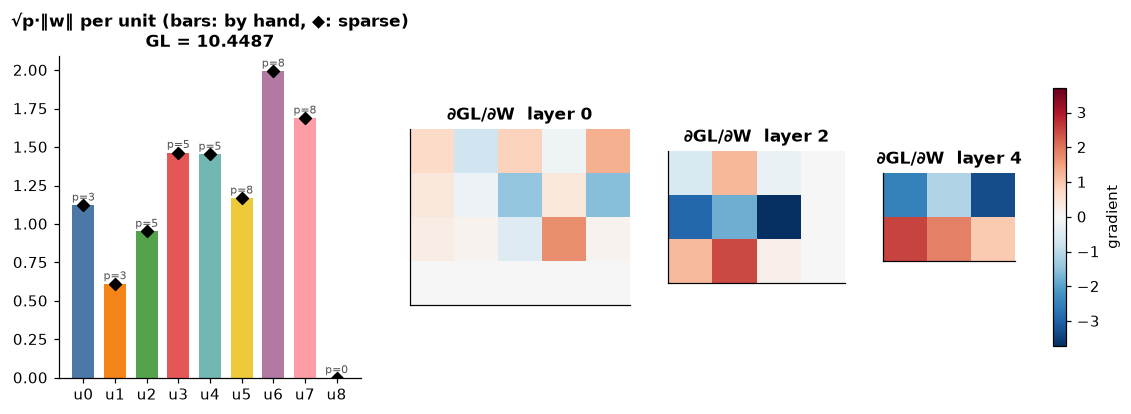

dead unit 8 (row 3 of layer 0, column 3 of layer 2) has exactly zero gradient: True


In [7]:
fig = plt.figure(figsize=(13, 3.8))
gs = fig.add_gridspec(1, 4, width_ratios=[5.5, 5, 4, 3])
ax = fig.add_subplot(gs[0])
units = np.arange(9)
ax.bar(units, terms_by_hand.numpy(), color=[color(u) for u in units], width=0.7)
ax.scatter(units, (p_u.sqrt() * norm_sparse).numpy(), marker="D", s=30, color="black", zorder=3)
for u in units:
    ax.text(u, terms_by_hand[u] + 0.03, f"p={int(p_u[u])}", ha="center", fontsize=7, color="#555")
ax.set_xticks(units, [f"u{u}" for u in units])
ax.set_title(f"√p·‖w‖ per unit (bars: by hand, ◆: sparse)\nGL = {gl_sparse:.4f}")

vmax = max(float(g.abs().max()) for g in g_sparse)
for i, (g, name) in enumerate(zip(g_sparse, ("0", "2", "4"))):
    ax = fig.add_subplot(gs[i + 1])
    im = ax.imshow(g, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set_title(f"∂GL/∂W  layer {name}")
    ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=fig.axes[1:], shrink=0.8, label="gradient")
plt.show()
print("dead unit 8 (row 3 of layer 0, column 3 of layer 2) has exactly zero gradient:",
      bool(g_sparse[0][3].abs().sum() == 0 and g_sparse[1][:, 3].abs().sum() == 0))

## 4. BOPs: structured compression under progressive pruning

Fake-prune (zero) random ResNet-20 units step by step and track `structured_bops` with both
backends. BOPs = MACs × weight bits × activation bits; a pruned channel removes MACs from
its own layer *and* from the layers that consume it. The two backends should trace the
same curve.

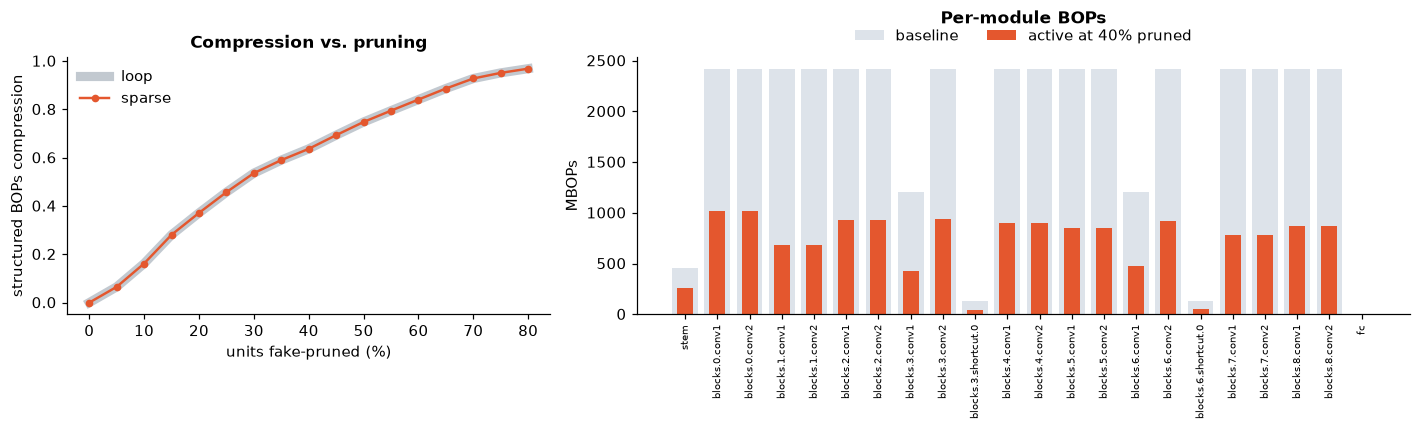

max |sparse - loop| over the curve: 0.0


In [8]:
torch.manual_seed(3)
bops_model = CifarResNet20().eval()
example = torch.randn(1, 3, 32, 32)
sparse_t, loop_t = tracker_pair(bops_model, example)
trackers = {
    "sparse": sparse_t.create_tracker("structured_bops", log_total_bops=True, log_layerwise_stats=True),
    "loop": loop_t.create_tracker("structured_bops", log_total_bops=True, log_layerwise_stats=True),
}

all_units = [(g.group_id, u) for g in sparse_t.canonical_groups for u in range(g.length)
             if g.length > 1]
order = torch.randperm(len(all_units)).tolist()
checkpoints = np.linspace(0, 0.8, 17)
curve = {"sparse": [], "loop": []}
snapshots = {}
pruned = 0
for frac in checkpoints:
    target = int(frac * len(all_units))
    while pruned < target:
        group_id, unit_id = all_units[order[pruned]]
        sparse_t.fake_prune_unit(group_id, unit_id)        # zeroes weights in place
        pruned += 1
    for name, trk in trackers.items():
        metrics = trk.track()["structured_bops"]
        curve[name].append(metrics["compression"])
        if abs(frac - 0.4) < 1e-9 or frac == 0:
            snapshots[(name, round(frac, 2))] = metrics["modules"]

np.testing.assert_allclose(curve["sparse"], curve["loop"], rtol=1e-6)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4), gridspec_kw={"width_ratios": [1, 1.6]})
a1.plot(checkpoints * 100, curve["loop"], "-", lw=6, color=LOOP_COLOR, alpha=0.6, label="loop")
a1.plot(checkpoints * 100, curve["sparse"], "o-", lw=1.6, ms=4, color=SPARSE_COLOR, label="sparse")
a1.set_xlabel("units fake-pruned (%)")
a1.set_ylabel("structured BOPs compression")
a1.set_title("Compression vs. pruning")
a1.legend(frameon=False)

base = snapshots[("sparse", 0.0)]
half = snapshots[("sparse", 0.4)]
mods = [m for m in base if base[m]["baseline"] > 0]
x = np.arange(len(mods))
a2.bar(x, [base[m]["baseline"] / 1e6 for m in mods], color="#DDE3EA", width=0.8, label="baseline")
a2.bar(x, [half[m]["bops"] / 1e6 for m in mods], color=SPARSE_COLOR, width=0.5, label="active at 40% pruned")
a2.set_xticks(x, mods, rotation=90, fontsize=6.5)
a2.set_ylabel("MBOPs")
a2.set_title("Per-module BOPs", pad=22)
a2.legend(frameon=False, ncol=2, loc="lower center", bbox_to_anchor=(0.5, 1.0))
plt.tight_layout()
plt.show()
print("max |sparse - loop| over the curve:", float(np.abs(np.array(curve["sparse"]) - curve["loop"]).max()))

## 5. Performance

**On this machine.** We run `sanity_checks/sparse_reduction_benchmark.py` live on ResNet-20
(it checks parity between the backends first). We also count the tensor ops dispatched per
call, which is a proxy for kernel launches on a GPU.

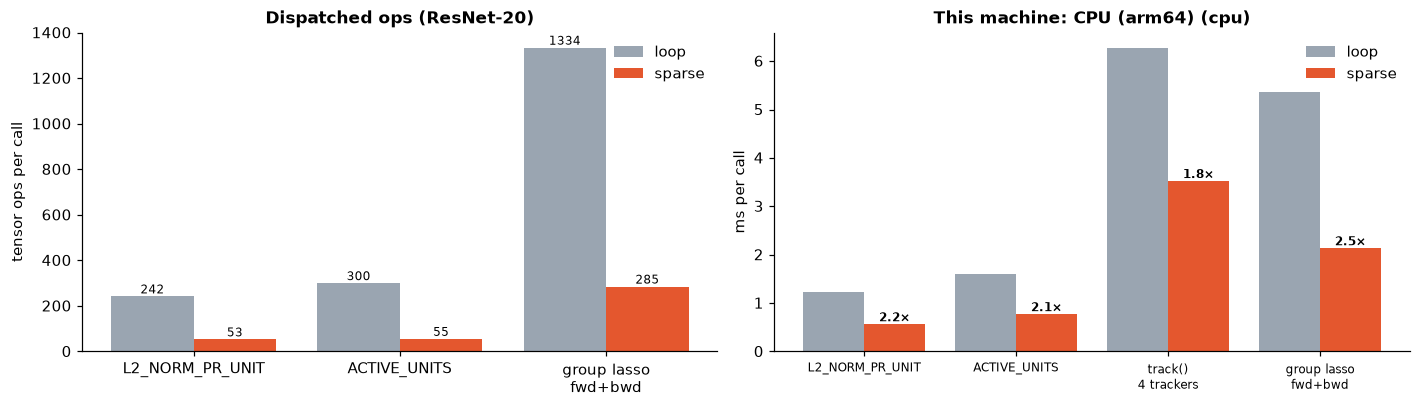

In [9]:
from torch.utils._python_dispatch import TorchDispatchMode
from sanity_checks import sparse_reduction_benchmark as bench

class OpCount(TorchDispatchMode):
    def __init__(self):
        super().__init__(); self.n = 0
    def __torch_dispatch__(self, func, types, args=(), kwargs=None):
        self.n += 1
        return func(*args, **(kwargs or {}))

def ops_per_call(fn):
    with OpCount() as counter:
        fn()
    return counter.n

model = CifarResNet20().eval(); bench.sparsify_(model)
sparse_t, loop_t = tracker_pair(model, torch.randn(1, 3, 32, 32))
op_rows = []
for label, make in (
    ("L2_NORM_PR_UNIT", lambda t: t.get_calculation(CalcType.L2_NORM_PR_UNIT)),
    ("ACTIVE_UNITS", lambda t: t.get_calculation(CalcType.ACTIVE_UNITS)),
    ("group lasso fwd+bwd", lambda t: (lambda r=t.create_regularizer("group_lasso"): r().backward())),
):
    op_rows.append((label, ops_per_call(make(loop_t)), ops_per_call(make(sparse_t))))

local = bench.run("resnet20", torch.device("cpu"), iters=100)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 3.8))
x = np.arange(len(op_rows))
a1.bar(x - 0.2, [r[1] for r in op_rows], 0.4, color=LOOP_COLOR, label="loop")
a1.bar(x + 0.2, [r[2] for r in op_rows], 0.4, color=SPARSE_COLOR, label="sparse")
for i, (_, lo, sp) in enumerate(op_rows):
    a1.text(i + 0.2, sp, f"{sp}", ha="center", va="bottom", fontsize=8)
    a1.text(i - 0.2, lo, f"{lo}", ha="center", va="bottom", fontsize=8)
a1.set_xticks(x, [r[0].replace(" fwd+bwd", "\nfwd+bwd") for r in op_rows]); a1.set_ylabel("tensor ops per call")
a1.set_title("Dispatched ops (ResNet-20)"); a1.legend(frameon=False)

rows = local["rows"]
x = np.arange(len(rows))
a2.bar(x - 0.2, [r["loop_ms"] for r in rows], 0.4, color=LOOP_COLOR, label="loop")
a2.bar(x + 0.2, [r["sparse_ms"] for r in rows], 0.4, color=SPARSE_COLOR, label="sparse")
for i, r in enumerate(rows):
    a2.text(i + 0.2, r["sparse_ms"], f"{r['speedup']:.1f}×", ha="center", va="bottom", fontsize=8, fontweight="bold")
a2.set_xticks(x, [r["case"].replace(" x4 trackers", "\n4 trackers").replace(" fwd+bwd", "\nfwd+bwd") for r in rows], fontsize=8); a2.set_ylabel("ms per call")
a2.set_title(f"This machine: {local['device_name']} ({local['device']})"); a2.legend(frameon=False)
plt.tight_layout(); plt.show()

**On Bob (RTX 3060).** Results recorded with
`python sanity_checks/sparse_reduction_benchmark.py --device cuda --models resnet20 resnet20x4 resnet50 --iters 200`
and stored in `sparse_reduction_benchmark_rtx3060.json`. Another training job shared the GPU
during the run, so `track()` timings (which include host-side metric conversion) are noisy.
The calculation and group-lasso rows are stable across runs.

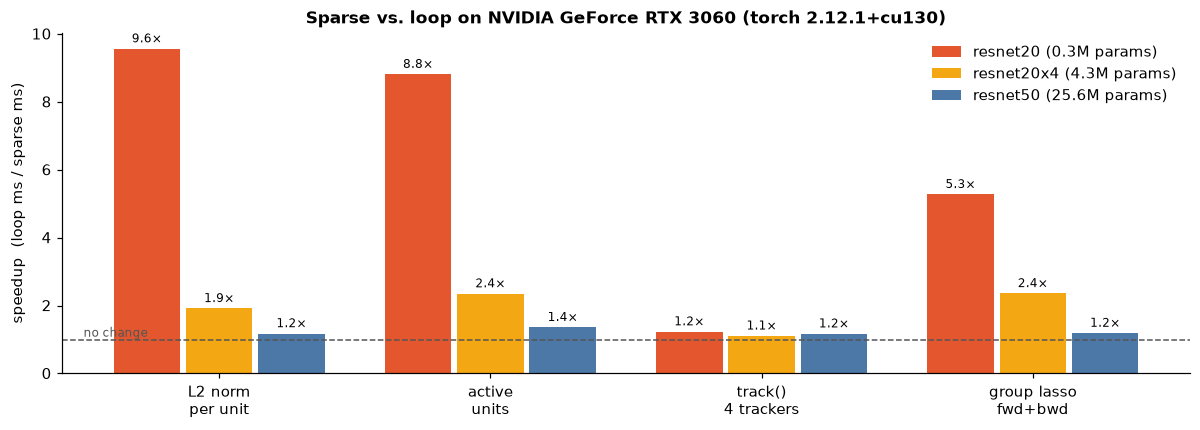

model       case                     loop ms  sparse ms  speedup
resnet20    L2_NORM_PR_UNIT            0.994      0.104     9.6x
resnet20    ACTIVE_UNITS               1.289      0.146     8.8x
resnet20    track() x4 trackers       29.672     24.107     1.2x
resnet20    group lasso fwd+bwd        7.124      1.351     5.3x
resnet20x4  L2_NORM_PR_UNIT            1.102      0.576     1.9x
resnet20x4  ACTIVE_UNITS               1.425      0.606     2.4x
resnet20x4  track() x4 trackers       29.420     26.573     1.1x
resnet20x4  group lasso fwd+bwd        6.191      2.628     2.4x
resnet50    L2_NORM_PR_UNIT            3.405      2.896     1.2x
resnet50    ACTIVE_UNITS               3.330      2.452     1.4x
resnet50    track() x4 trackers       76.744     65.632     1.2x
resnet50    group lasso fwd+bwd       16.192     13.630     1.2x


In [10]:
import json
gpu = json.loads((REPO / "sanity_checks" / "sparse_reduction_benchmark_rtx3060.json").read_text())
short = {"L2_NORM_PR_UNIT": "L2 norm\nper unit", "ACTIVE_UNITS": "active\nunits",
         "track() x4 trackers": "track()\n4 trackers", "group lasso fwd+bwd": "group lasso\nfwd+bwd"}
cases = [r["case"] for r in gpu[0]["rows"]]
model_colors = ["#E4572E", "#F3A712", "#4C78A8"]

fig, ax = plt.subplots(figsize=(11, 4))
width = 0.8 / len(gpu)
x = np.arange(len(cases))
for k, result in enumerate(gpu):
    speedups = [r["speedup"] for r in result["rows"]]
    bars = ax.bar(x + (k - (len(gpu) - 1) / 2) * width, speedups, width * 0.92,
                  color=model_colors[k], label=f"{result['model']} ({result['params'] / 1e6:.1f}M params)")
    for bar, value in zip(bars, speedups):
        ax.text(bar.get_x() + bar.get_width() / 2, value + 0.1, f"{value:.1f}×",
                ha="center", va="bottom", fontsize=8)
ax.axhline(1, color="#555", ls="--", lw=1)
ax.text(-0.5, 1.08, "no change", fontsize=8, color="#555", ha="left")
ax.set_xticks(x, [short[c] for c in cases])
ax.set_ylabel("speedup  (loop ms / sparse ms)")
ax.set_title(f"Sparse vs. loop on {gpu[0]['device_name']} (torch {gpu[0]['torch']})")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

print(f"{'model':11s} {'case':22s} {'loop ms':>9s} {'sparse ms':>10s} {'speedup':>8s}")
for result in gpu:
    for r in result["rows"]:
        print(f"{result['model']:11s} {r['case']:22s} {r['loop_ms']:9.3f} {r['sparse_ms']:10.3f} {r['speedup']:7.1f}x")

**Why the gain shrinks on big models.** The win comes from removing per-op launch overhead,
which dominates small layers. Large weight tensors already reduce efficiently with dense
kernels, and lowering them would cost one sparse index per element of memory traffic. So ops
whose source has more than `MAX_LOWERED_SOURCE_ELEMENTS` (2¹⁸) elements stay on the loop
path, and the rest are lowered. Opt out entirely with
`WeightTracker(..., reduction_backend="loop")`.